In [2]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(seed=SEED)

In [3]:
df_path = "../data/data.csv"

df = pd.read_csv(
    filepath_or_buffer=df_path,
    engine='c',
    low_memory=True,
    dtype={'value': 'Int32'},  
    parse_dates=['timestamp'],
    on_bad_lines='skip'
)

df = df.sort_values(
    by='timestamp', 
    kind='quicksort'
).reset_index(drop=True)

## Data understanding

In [4]:
df.head(5)

,timestamp,value
0,2023-12-06 15:03:53.908288,1019
1,2023-12-06 15:03:53.908288,1019
2,2023-12-06 15:03:53.908288,1018
3,2023-12-06 15:03:53.908288,775
4,2023-12-06 15:03:53.908288,377


In [5]:
df.tail(5)

,timestamp,value
1505473,2023-12-06 17:22:20.208483,231
1505474,2023-12-06 17:22:20.208483,1018
1505475,2023-12-06 17:22:20.208483,1018
1505476,2023-12-06 17:22:20.208483,4
1505477,2023-12-06 17:22:20.224139,1019


## Null values

In [6]:
df.isnull().sum()

timestamp    0
value        0
dtype: int64

## Data Overview

In [7]:
df.describe()

,timestamp,value
count,1505478,1505478.0
mean,2023-12-06 16:17:54.366596,512.161045
min,2023-12-06 15:03:53.908288,0.0
25%,2023-12-06 15:50:23.973030,5.0
50%,2023-12-06 16:07:45.271305,511.0
75%,2023-12-06 16:53:34.402754,1018.0
max,2023-12-06 17:22:20.224139,1021.0
std,NaN,447.397613


## First Time Window

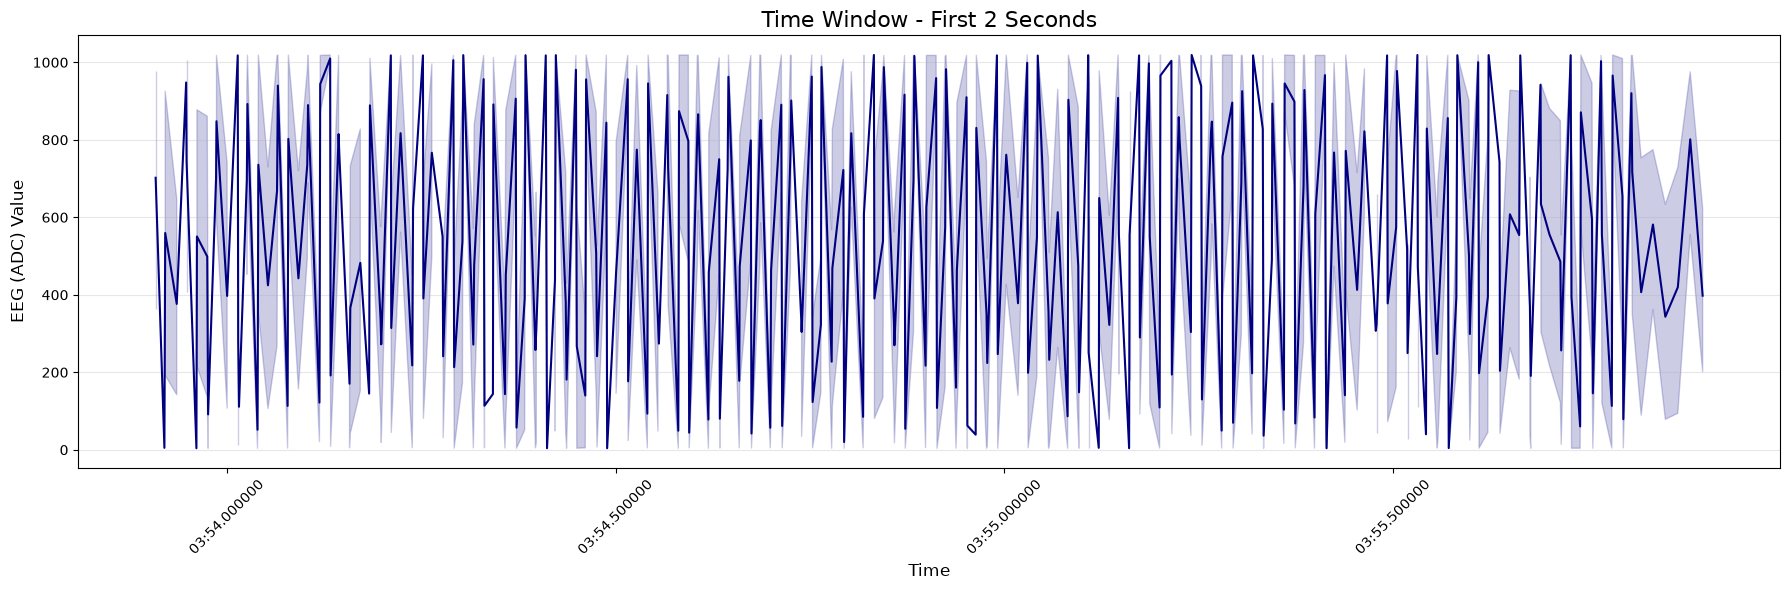

In [9]:
start_time = df['timestamp'].min()
df_first_2s = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= start_time + pd.Timedelta(seconds=2))]

plt.figure(figsize=(18, 6))
sns.lineplot(data=df_first_2s, x='timestamp', y='value', color='navy', linewidth=1.5)

plt.title('Time Window - First 2 Seconds', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('EEG (ADC) Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Insights: 

### Data Features: 

* The data has two features: 'timestamp' and 'value'. 
* 'timestamp' shows the time at which the signal was captures upto micro-seconds precision.
* 'value' is an output of Arduino's 10-bit ADC (0-1024) which was previously obtained from forehead's amplified EEG voltage value (0-5 V).

### Missing Value Analysis: 

* No missing values found.

### Outlier Analysis: 

* The minimum 'value' is 0.0 while the maximum 'value' is 1021.0, both the values lie in the range of Arduino's 10-bit ADC. Hence, no outliers detected. 

### Strategy: 

* Data will be preprocessed using fixed-window segmentation. 
* By framing the dataset into consistent 2-second intervals, each instance will represent a uniform  duration which will be useful for brain wave classification.

